# Rainbow

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching Rainbow radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("2013051000000600dBZ.vol")

## xr.open_dataset

Making use of the xarray `rainbow` backend. We also need to provide the group. Note, that we are using CfRadial2 group access pattern.

In [3]:
ds = xr.open_dataset(filename, group="sweep_0", engine="rainbow")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 1MB
Dimensions:            (azimuth: 361, range: 400)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5055 1.549 2.505 ... 358.5 359.5
    elevation          (azimuth) float64 3kB ...
  * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
    time               (azimuth) datetime64[ns] 3kB ...
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables:
    DBZH               (azimuth, range) float64 1MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...

### Plot Time vs. Azimuth

We need to sort by time and specify the coordinate.

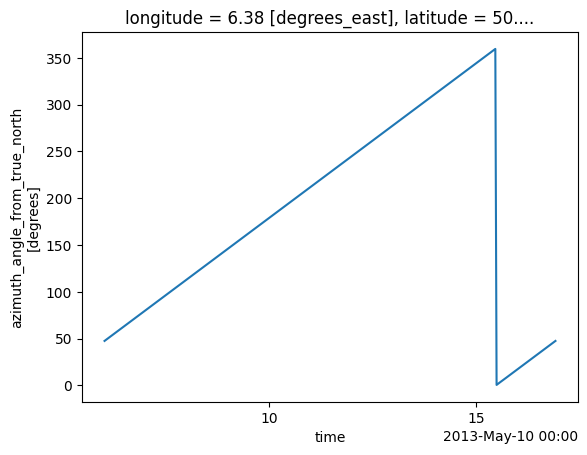

In [4]:
ds.azimuth.sortby("time").plot(x="time")

### Plot Range vs. Time

We need to sort by time and specify the coordinate.

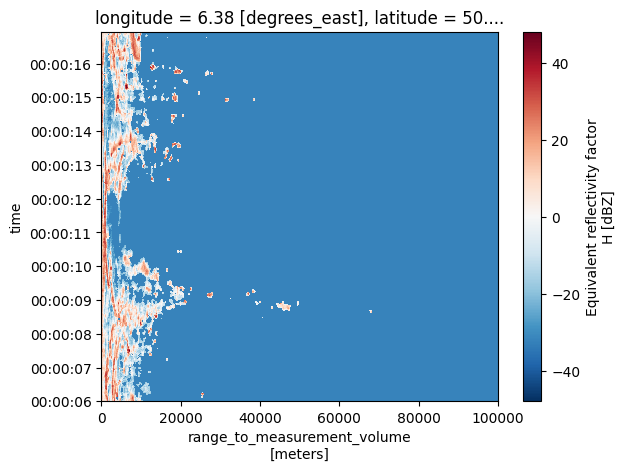

In [5]:
ds.DBZH.sortby("time").plot(y="time")

### Plot Range vs. Azimuth


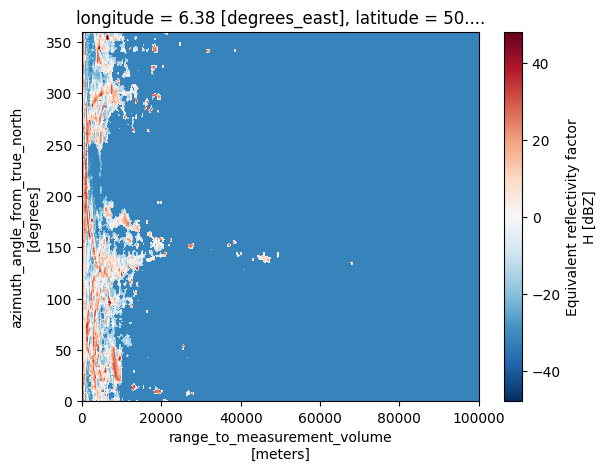

In [6]:
ds.DBZH.plot()

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the rainbow backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [7]:
help(xd.io.RainbowBackendEntrypoint)

Help on class RainbowBackendEntrypoint in module xradar.io.backends.rainbow:

class RainbowBackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for Rainbow5 data.
 |
 |  Method resolution order:
 |      RainbowBackendEntrypoint
 |      xarray.backends.common.BackendEntrypoint
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  open_dataset(
 |      self,
 |      filename_or_obj,
 |      *,
 |      mask_and_scale=True,
 |      decode_times=True,
 |      concat_characters=True,
 |      decode_coords=True,
 |      drop_variables=None,
 |      use_cftime=None,
 |      decode_timedelta=None,
 |      group=None,
 |      reindex_angle=False,
 |      first_dim='auto',
 |      site_coords=True
 |  )
 |      Backend open_dataset method used by Xarray in :py:func:`~xarray.open_dataset`.
 |
 |  ----------------------------------------------------------------------
 |  Data and other attributes defined here:
 |
 |  __annotations__ = {}
 |
 |  description 

In [8]:
ds = xr.open_dataset(filename, group="sweep_1", engine="rainbow", first_dim="time")
display(ds)

<xarray.Dataset> Size: 1MB
Dimensions:            (time: 361, range: 400)
Coordinates:
    azimuth            (time) float64 3kB ...
    elevation          (time) float64 3kB ...
  * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
  * time               (time) datetime64[ns] 3kB 2013-05-10T00:00:19.01515150...
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables:
    DBZH               (time, range) float64 1MB ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...

## open_odim_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list.

In [9]:
help(xd.io.open_rainbow_datatree)

Help on function open_rainbow_datatree in module xradar.io.backends.rainbow:

open_rainbow_datatree(filename_or_obj, **kwargs)
    Open ODIM_H5 dataset as :py:class:`xarray.DataTree`.

    Parameters
    ----------
    filename_or_obj : str, Path, file-like or DataStore
        Strings and Path objects are interpreted as a path to a local or remote
        radar file

    Keyword Arguments
    -----------------
    sweep : int, list of int, optional
        Sweep number(s) to extract, default to first sweep. If None, all sweeps are
        extracted into a list.
    first_dim : str
        Can be ``time`` or ``auto`` first dimension. If set to ``auto``,
        first dimension will be either ``azimuth`` or ``elevation`` depending on
        type of sweep. Defaults to ``auto``.
    reindex_angle : bool or dict
        Defaults to False, no reindexing. Given dict should contain the kwargs to
        reindex_angle. Only invoked if `decode_coord=True`.
    fix_second_angle : bool
        I

In [10]:
dtree = xd.io.open_rainbow_datatree(filename, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-05-10T00:01:55Z'
│       time_coverage_end    <U20 80B '2013-05-10T00:02:05Z'
│       longitude            float64 8B 6.38
│       altitude             float64 8B 116.7
│       latitude             float64 8B 50.86
│       sweep_fixed_angle    (sweep) float64 8B 12.2
│       sweep_group_name     (sweep) int64 8B 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5 1.544 2.51 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:02:03.10606...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration

### Plot Sweep Range vs. Time

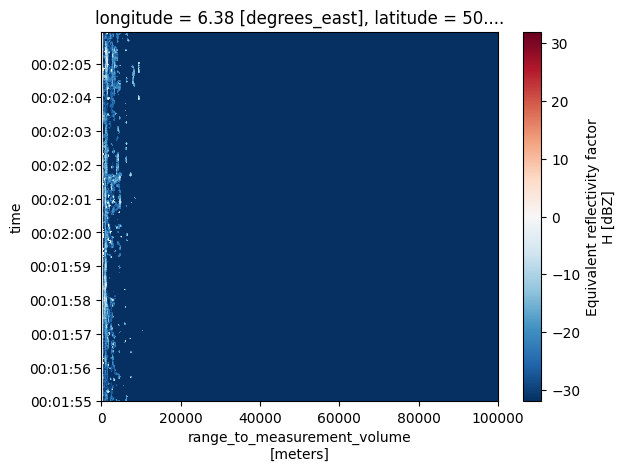

In [11]:
dtree["sweep_0"].ds.DBZH.sortby("time").plot(y="time")

### Plot Sweep Range vs. Azimuth

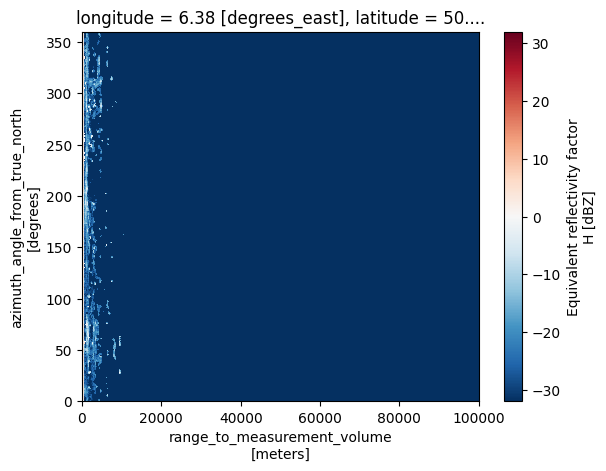

In [12]:
dtree["sweep_0"].ds.DBZH.plot()

In [13]:
dtree = xd.io.open_rainbow_datatree(filename, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-05-10T00:01:55Z'
│       time_coverage_end    <U20 80B '2013-05-10T00:02:05Z'
│       longitude            float64 8B 6.38
│       altitude             float64 8B 116.7
│       latitude             float64 8B 50.86
│       sweep_fixed_angle    (sweep) float64 8B 12.2
│       sweep_group_name     (sweep) int64 8B 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5 1.544 2.51 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:02:03.10606...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration

In [14]:
dtree = xd.io.open_rainbow_datatree(filename, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-05-10T00:00:19Z'
│       time_coverage_end    <U20 80B '2013-05-10T00:02:19Z'
│       longitude            float64 8B 6.38
│       altitude             float64 8B 116.7
│       latitude             float64 8B 50.86
│       sweep_fixed_angle    (sweep) float64 24B 1.4 2.4 14.8
│       sweep_group_name     (sweep) int64 24B 1 2 9
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5055 1.549 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:00:25.62121...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.511 1.505 2.505 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:00:36.65151...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.522 1.516 2.51 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:02:14.19696...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B 6.38
│           latitude   float64 8B 50.86
│           altitude   float64 8B 116.7
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B 6.38
│           latitude   float64 8B 50.86
│           altitude   float64 8B 116.7
└── Group: /radar_calibration

In [15]:
dtree = xd.io.open_rainbow_datatree(filename, sweep=["sweep_1", "sweep_2", "sweep_8"])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2013-05-10T00:00:19Z'
│       time_coverage_end    <U20 80B '2013-05-10T00:02:05Z'
│       longitude            float64 8B 6.38
│       altitude             float64 8B 116.7
│       latitude             float64 8B 50.86
│       sweep_fixed_angle    (sweep) float64 24B 1.4 2.4 12.2
│       sweep_group_name     (sweep) int64 24B 1 2 8
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           None
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5055 1.549 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:00:25.62121...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.511 1.505 2.505 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:00:36.65151...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 361, range: 400)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5 1.544 2.51 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│         * range              (range) float32 2kB 125.0 375.0 ... 9.962e+04 9.988e+04
│           time               (azimuth) datetime64[ns] 3kB 2013-05-10T00:02:03.10606...
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables:
│           DBZH               (azimuth, range) float64 1MB ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B 6.38
│           latitude   float64 8B 50.86
│           altitude   float64 8B 116.7
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B 6.38
│           latitude   float64 8B 50.86
│           altitude   float64 8B 116.7
└── Group: /radar_calibration